In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

import torch
from torch import nn
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning import callbacks 

from src import PATH

In [2]:
from torch.utils.data import DataLoader, Dataset, TensorDataset

In [3]:
adata_diff = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")

In [4]:
adata_diff

AnnData object with n_obs × n_vars = 28825 × 4806
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'discrete_time', 'split', 'cell_type', 'Cluster Enriched TFs_colors', 'highlight_celltype', 'Depth_from_root', 'Cluster Enriched TFs'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Cluster Enriched TFs_colors', 'KNN', 'batch_colors', 'diffmap_evals', 'highlight_celltype_colors', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'umap', 'unique_token_dict'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'a2_PathSampled_X', 'a3_PathSampled_X'
    obsp: 'KNN_connectivities', 'KNN_distances', 'connectivities', 'distances'

# Tensor ds

In [21]:
TF_onehot = pd.get_dummies(adata_diff.obs.TF).values
gene_X = adata_diff.obsm['X_pca']
# gene_X = adata_diff.X
X =  np.concatenate([gene_X, TF_onehot], axis=1)
print(X.shape)
Y = adata_diff.layers['a3_PathSampled_X'].copy()

train_idx = adata_diff.obs.split != 'test'
test_idx = adata_diff.obs.split == 'test'

x_train = torch.from_numpy(X[train_idx]).float()
x_test = torch.from_numpy(X[test_idx]).float()

Y_train = torch.from_numpy(Y[train_idx]).float()
Y_test = torch.from_numpy(Y[test_idx]).float()

(28825, 7341)


In [23]:
gene_X.shape

(28825, 4806)

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

## draw

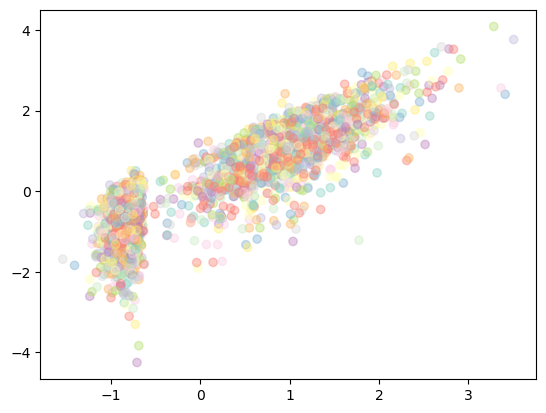

In [39]:
plt.scatter(x_test[:,515], Y_test[:,515], alpha=0.4,
            c=np.argmax(x_test[:,4806:], axis=1),cmap='Set3')

In [30]:
mesen = sc.read_h5ad("/home/wergillius/Project/diffuse_differentiate/data/integrated_mesendo_group_Nov4.h5ad")

In [33]:
mesen

AnnData object with n_obs × n_vars = 5802 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RA', 'Wnt', 'TgfB', 'Bmp', 'Fgf', 'Notch', 'Shh', 'assignment', 'starting.state', 'dataset', 'control', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'dpt_pseudotime', 'discrete_time', 'split', 'time_slot'
    var: 'features'
    uns: 'assignment_colors', 'diff', 'diffmap_evals', 'dpt_changepoints', 'dpt_groups_colors', 'dpt_grouptips', 'iroot', 'neighbors', 'umap', 'unique_token_dict'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'diff_connectivities', 'diff_distances', 'distances'

In [35]:
conditions = mesen.obs[['RA', 'Wnt', 'TgfB', 'Bmp', 'Fgf', 'Notch', 'Shh']].values

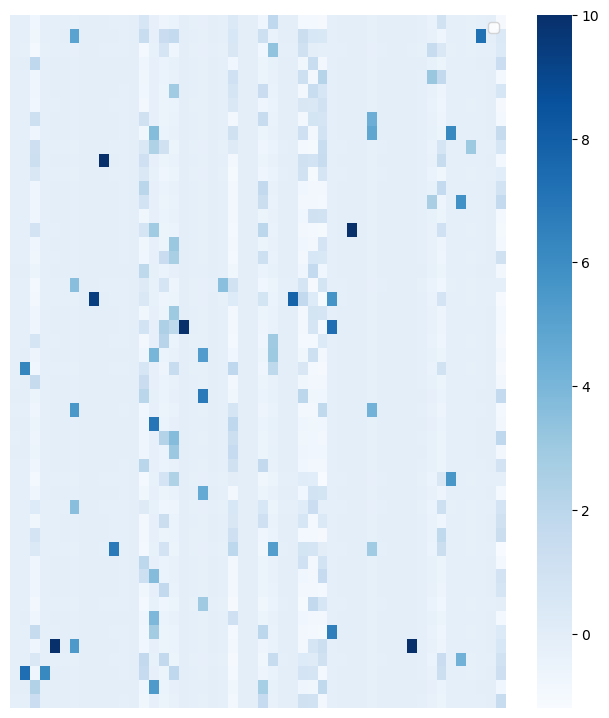

In [24]:
fig, ax = plt.subplots(1,1, figsize=(8,9))
sns.heatmap(conditions[:50,:50],cmap='Blues', ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.legend([])

In [6]:
train_ds = TensorDataset(x_train, Y_train)
train_dl = DataLoader(train_ds, batch_size=32, num_workers=8, shuffle=True)

test_ds = TensorDataset(x_test, Y_test)
test_dl = DataLoader(test_ds, batch_size=32,  num_workers=8, shuffle=False)

In [7]:
x_train.shape

torch.Size([25942, 2585])

# model

In [8]:
from importlib import reload
from src import _helper_net

In [9]:
reload(_helper_net)

<module 'src._helper_net' from '/home/wergillius/Project/diffuse_differentiate/src/_helper_net.py'>

In [10]:
from scipy.stats import pearsonr

def evaluate_r(test_Y, pred_Y):

    r_dict = []
    for i, gene in enumerate(adata_diff.var.index):
        r_dict.append(
            {"gene":gene, 'r2': pearsonr(test_Y[:,i], pred_Y[:,i])[0]**2}
        )

    return pd.json_normalize(r_dict)

In [60]:
class base(pl.LightningModule):
    def __init__(self, input_dim, output_dim, lr, weight_decay):
        super().__init__()

        self.save_hyperparameters()

        self.lr = lr
        self.weight_decay = weight_decay

        self.loss_fn = nn.MSELoss()

        self.train_r2_score = torchmetrics.R2Score(num_outputs = output_dim)
        self.val_r2_score = torchmetrics.R2Score(num_outputs = output_dim)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        return optimizer
    
    def forward(self,X):
        raise NotImplementedError("not defined")
    
    def training_step(self, train_batch, batch_idx):
        X,Y = train_batch
        Ypred= self.forward(X)
        loss = self.loss_fn(Y, Ypred)
        r2 = self.train_r2_score(Y, Ypred)
        self.log_dict({'train_loss':loss, 'train_r2':r2})
        return loss

    def validation_step(self, val_batch, batch_idx):
        X,Y = val_batch
        Ypred= self.forward(X)
        loss = self.loss_fn(Y, Ypred)
        r2 = self.val_r2_score(Y,Ypred)
        self.log_dict({'val_loss':loss, 'val_r2':r2})
        return loss

    def test_step(self, test_batch, batch_idx):
        X,Y = test_batch
        Ypred= self.forward(X)
        loss = self.loss_fn(Y, Ypred)
        self.log_dict({'test_loss':loss})
        return loss

class Linear_model(base):
    def __init__(input_dim, output_dim, lr, weight_decay):
        super().__init__(input_dim, output_dim, lr, weight_decay)
        
        self.model = nn.Linear(input_dim,output_dim)
    
    def forward(self, X):
        return self.model(X)


class CAE_model(Linear_model):
    def __init__(self, input_dim, output_dim, hidden, lr, weight_decay):
        super().__init__(input_dim, output_dim, lr, weight_decay)

        bottlenet = (len(hidden)-1)//2
        self.latent = hidden[bottlenet]

        encoder_dims = [input_dim] + hidden[:bottlenet+1]
        decoder_dims = hidden[bottlenet:]
        self.encoder = _helper_net.MLP(encoder_dims, use_batchnorm=True, use_dropout=0)
        

        self.decoder = nn.Sequential(
            _helper_net.MLP(decoder_dims, use_batchnorm=True, use_dropout=0),
            nn.Linear(hidden[-1], output_dim)
            )

        self.model = nn.Sequential(
             self.encoder,
             self.decoder
        )

    def encode(self, X):
        return self.encoder(X)

    def forward(self, X):
        z = self.encode(X)
        return self.decoder(z)
    
class Embedding_model(base):
    def __init__(self, gene_dim, embedding_dim, output_dim, hidden, lr, weight_decay):
        super().__init__(gene_dim, output_dim, lr, weight_decay)

        bottlenet = (len(hidden)-1)//2
        self.latent = hidden[bottlenet]

        encoder_dims = [gene_dim] + hidden[:bottlenet+1]
        decoder_dims = hidden[bottlenet:]
        decoder_dims[0] = self.latent + 32

        self.encoder = _helper_net.MLP(encoder_dims, use_batchnorm=True, use_dropout=0)
        
        self.embedder = nn.Embedding(embedding_dim, 32)

        self.decoder = nn.Sequential(
            _helper_net.MLP(decoder_dims, use_batchnorm=True, use_dropout=0),
            nn.Linear(hidden[-1], output_dim)
            )

    def encode(self, X):
        X_gene = X[:,:50]
        X_condition = torch.argmax(X[:,50:], dim=1)

        Z_x = self.encoder(X_gene)
        Z_c = self.embedder(X_condition)

        return torch.concat([Z_x , Z_c], axis=1)

    def forward(self, X):
        z = self.encode(X)
        return self.decoder(z)

In [41]:
X.shape, Y.shape

((28825, 2585), (28825, 4806))

# training

In [42]:
L_M = Linear_model(2585,4806, 3e-4,1e-9)

In [22]:
Trainer = pl.Trainer(accelerator='gpu', gpus=[0],
                     default_root_dir = PATH.pth_dir+'/PCA_based',
                     callbacks=[
                         callbacks.ModelCheckpoint(save_top_k=2, monitor="val_loss"),
                         callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=10)
                         ],
                    )

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:467: LightningDeprecationWarning: Setting `Trainer(gpus=[0])` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=[0])` instead.
  rank_zero_deprecation(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [23]:
Trainer.fit(L_M, train_dataloaders=train_dl, 
            val_dataloaders=test_dl)

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/pytorch_lightning/loops/utilities.py:94: PossibleUserWarning: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name           | Type    | Params
-------------------------------------------
0 | model          | Linear  | 12.4 M
1 | loss_fn        | MSELoss | 0     
2 | train_r2_score | R2Score | 0     
3 | val_r2_score   | R2Score | 0     
-------------------------------------------
12.4 M    Trainable params
0         Non-trainable params
12.4 M    Total params
49.713    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

In [28]:
VAE = CAE_model(2585,4806, hidden=[2048,1024,2048],
         lr=3e-4,weight_decay=1e-5)

In [29]:
Trainer = pl.Trainer(accelerator='gpu', gpus=[0], auto_lr_find=True,
                     default_root_dir = PATH.pth_dir + '/PCA_based',
                     callbacks=[
                         callbacks.ModelCheckpoint(save_top_k=2, monitor="val_loss"),
                         callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=10)
                         ],
                    )

Trainer.fit(VAE, train_dataloaders=train_dl, 
            val_dataloaders=test_dl)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name           | Type       | Params
----------------------------------------------
0 | model          | Sequential | 19.3 M
1 | loss_fn        | MSELoss    | 0     
2 | train_r2_score | R2Score    | 0     
3 | val_r2_score   | R2Score    | 0     
4 | encoder        | MLP        | 7.4 M 
5 | decoder        | Sequential | 11.9 M
----------------------------------------------
19.3 M    Trainable params
0         Non-trainable params
19.3 M    Total params
77.380    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x155334864310>
Traceback (most recent call last):
  File "/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1510, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x155334864310>
    Traceback (most recent call last):
self._shutdown_workers()  File "/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1510, in __del__

  File "/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 1493, in _shutdown_workers
        if w.is_alive():
  File "/home/wergillius/.conda/envs/GenDiff/lib/python3.8/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: Exception ignored in: <function _MultiProcessing

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

## train embedding model

In [61]:
Emb_VAE = Embedding_model(50, 2535, 4806, hidden=[2048,1024,2048],
         lr=3e-4,weight_decay=1e-5)

In [62]:
Trainer = pl.Trainer(accelerator='gpu', gpus=[0], auto_lr_find=True,
                     default_root_dir = PATH.pth_dir + '/PCA_based',
                     callbacks=[
                         callbacks.ModelCheckpoint(save_top_k=2, monitor="val_loss"),
                         callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=10)
                         ],
                    )

Trainer.fit(Emb_VAE, train_dataloaders=train_dl, 
            val_dataloaders=test_dl)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name           | Type       | Params
----------------------------------------------
0 | loss_fn        | MSELoss    | 0     
1 | train_r2_score | R2Score    | 0     
2 | val_r2_score   | R2Score    | 0     
3 | encoder        | MLP        | 2.2 M 
4 | embedder       | Embedding  | 81.1 K
5 | decoder        | Sequential | 12.0 M
----------------------------------------------
14.3 M    Trainable params
0         Non-trainable params
14.3 M    Total params
57.200    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

# predict

In [19]:
L_M = Linear_model.load_from_checkpoint('/home/wergillius/data/diffuse_differentiate/lightning_logs/version_2/checkpoints/epoch=14-step=12165.ckpt',
                                        output_dim=4806, lr=3e-4, weight_decay=1e-3, input_dim=7341)

In [75]:
VAE = CAE_model.load_from_checkpoint('/home/wergillius/data/diffuse_differentiate/lightning_logs/version_7/checkpoints/epoch=24-step=20275.ckpt')

In [12]:
VAE = CAE_model.load_from_checkpoint('/home/wergillius/data/diffuse_differentiate/quick_CVAE/lightning_logs/version_7/checkpoints/epoch=24-step=20275.ckpt')

In [21]:
Y_pred = []
with torch.no_grad():
    for X,Y in test_dl:
        Y_pred.append( L_M(X) )

In [13]:
VAE = VAE.eval().to('cpu');

Y_pred_CAE = []
with torch.no_grad():
    for X,Y in test_dl:
        Y_pred_CAE.append( VAE(X) )

In [14]:
ypred_CAE = torch.concat(Y_pred_CAE)
rdf_CAE = evaluate_r(ypred_CAE, Y_test)

In [17]:
rdf_CAE.to_csv("/home/wergillius/Project/diffuse_differentiate/result/TFAtlas/CAE_performance.csv")

In [22]:
ypred = torch.concat(Y_pred)
rdf = evaluate_r(ypred, Y_test)

In [24]:
rdf.to_csv("/home/wergillius/Project/diffuse_differentiate/result/TFAtlas/LinearModel_performance.csv")

In [66]:
ypred_L1 = torch.concat(Y_pred_L1)
rdf_L1 = evaluate_r(ypred_L1, Y_test)

In [67]:
rdf_L1

,gene,r2
0,A2M,0.081937
1,AADACL3,0.059327
2,ABCA1,0.389042
3,ABCA12,0.104837
4,ABCA13,0.064254
...,...,...
4801,ZRANB3,0.327969
4802,ZRSR2,0.210350
4803,ZSCAN1,0.157768
4804,ZSWIM6,0.281093


In [68]:
rdf.r2.max()

0.7024984154266845

In [44]:
ypred = torch.concat(Y_pred)

In [46]:
ypred.shape

torch.Size([2883, 4806])